# TP Integrador — Ciencia de Datos
## Análisis del Mercado Inmobiliario Argentino (Zonaprop)

---

### Integrantes

| Nombre | 
|---|
| Tejerina, Mariano |
| Bonifacio, Leandro |
| Quiroga, Emiliano |
| Gomez Morales, Luis |

In [42]:
# Instalación de dependencias del proyecto
!pip install pandas matplotlib seaborn requests


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [43]:
# Importación de librerías y configuración global

import os
import requests
import pandas as pd
import os
import sys
import re
import seaborn as sns
import matplotlib.pyplot as plt

print("Librerías cargadas exitosamente y configuración inicial completa.")

Librerías cargadas exitosamente y configuración inicial completa.


In [44]:
def configurar_git():
  """Configura el entorno de Git según el host (Colab o Local)."""
  IN_COLAB = 'google.colab' in sys.modules
  if IN_COLAB:
    repo_url = "https://github.com/GomezMorales/TP_INTEGRADOR_CIENCIAS_DE_DATOS.git"
    repo_name = "TP_INTEGRADOR_CIENCIAS_DE_DATOS"
    if not os.path.exists(repo_name):
      !git clone -b Sprint_2 {repo_url}

    %cd {repo_name}

configurar_git()

## Comprensión del negocio (Business Understanding -  CRISP-DM)

### Contexto del problema
El dataset pertenece al sector inmobiliario, específicamente a anuncios de propiedades publicadas en Zonaprop Argentina.
En el se incluye información típica del mercado: precios, ubicación, características físicas de las propiedades y atributos adicionales.

##### Relevancia
El mercado inmobiliario es un sector clave para compradores, vendedores, inversores, inmobiliarias y desarrolladores.
El análisis de datos permite entender tendencias de precios, demanda por zonas y características más valoradas,
aportando información útil para optimizar decisiones de inversión, estrategias comerciales y tasaciones.

##### Quién puede beneficiarse
* Inmobiliarias y agentes: para fijar precios adecuados y entender qué oferta tiene más demanda.
* Compradores/inversores: para identificar oportunidades y comparar zonas.
* Desarrolladores: para decidir dónde construir y qué tipo de vivienda ofrecer.
* Plataformas de venta/alquiler: para mejorar recomendaciones y segmentación de usuarios.

### Formulación del problema
¿Qué factores determinan el precio de una propiedad en el mercado
inmobiliario argentino, y cómo pueden los datos de Zonaprop ayudar
a entender y predecir esas variaciones?

### Objetivos del análisis (perspectiva del negocio)
* Identificar los principales determinantes del precio de una propiedad (por ejemplo, superficie, ubicación, cantidad de ambientes).
* Comprender cómo varían los precios entre diferentes barrios, ciudades o provincias.
* Detectar patrones que permitan caracterizar la oferta: tipos de propiedades más comunes, rangos de precio, características frecuentes.
* Apoyar decisiones estratégicas del negocio, como tasaciones, recomendaciones o inversión inmobiliaria.

### Preguntas analíticas que guiarán el trabajo
* ¿Cuáles son los factores más relacionados con el precio de una propiedad (superficie, ubicación, cantidad de ambientes, características adicionales)?
* ¿Cómo varían los precios promedio entre distintas zonas o ciudades dentro de Argentina?
* ¿Qué tipos de propiedades (casas, departamentos, PH, etc.) predominan en la oferta y cómo se diferencian en precio y características?

## Compresión de los datos (Data Understanding - CRISP-DM)

### Fuente de datos, obtención y condiciones de uso

El dataset fue obtenido del repositorio público de GitHub de Bright Data:
https://github.com/luminati-io/Zonaprop-Argentina-dataset-samples

Los datos fueron extraídos de Zonaprop Argentina mediante la API de
Bright Data (web scraping), y corresponden a anuncios de propiedades
inmobiliarias publicados en la plataforma.

El repositorio es público y de acceso libre. Bright Data ofrece acceso
gratuito a sus datasets para investigadores académicos y organizaciones
sin fines de lucro a través del programa Bright Initiative
(brightinitiative.com). El uso del dataset en este trabajo es con
fines estrictamente académicos.

### Limitación del dataset

Es importante señalar que este conjunto de datos es una **muestra de
demostración** publicada por Bright Data como ejemplo de su producto
comercial, y no necesariamente constituye una muestra aleatoria
representativa del universo de publicaciones de Zonaprop Argentina.
Esto implica que los resultados del análisis deben interpretarse como
descriptivos de este dataset en particular, y no como conclusiones
generalizables al mercado inmobiliario argentino en su totalidad.
Esta limitación será tenida en cuenta a lo largo del análisis.

In [45]:
# Carga del dataset
df = pd.read_csv('data/raw/Zonaprop Argentina - Properties Listing.csv')

# Estructura del dataset
print(f"Cantidad de filas: {df.shape[0]}")
print(f"Cantidad de columnas: {df.shape[1]}")

display(df.info())
display(df.head())

Cantidad de filas: 1000
Cantidad de columnas: 38
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 38 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   url                   1000 non-null   str    
 1   Title                 1000 non-null   str    
 2   generatedTitle        996 non-null    str    
 3   Imagenes              1000 non-null   str    
 4   Numero_de_imagenes    1000 non-null   int64  
 5   Description           1000 non-null   str    
 6   Precio                996 non-null    float64
 7   Currency              996 non-null    str    
 8   Fecha_de_publicacion  1000 non-null   str    
 9   Visualizaciones       484 non-null    float64
 10  Dimension_terreno     978 non-null    float64
 11  Dimension_propiedad   768 non-null    float64
 12  Ambientes             1000 non-null   int64  
 13  Banos                 1000 non-null   int64  
 14  Dormitorios           1000 non-null

None

,url,Title,generatedTitle,Imagenes,Numero_de_imagenes,Description,Precio,Currency,Fecha_de_publicacion,Visualizaciones,...,Superdestacado,Premium_label,posting_id,proveedor_tour,estatus,latitude,longitude,address,seller_level,expenses
0,https://www.zonaprop.com.ar/propiedades/clasif...,Terreno en Venta - 366 m² - San Miguel del Monte,Terreno en Venta - 366 m² - San Miguel del Monte,"[""https://imgar.zonapropcdn.com/avisos/1/00/58...",14,_ Terreno en venta ubicado sobre calle Río Gua...,26000.0,USD,1/9/26,NaN,...,simple,Anunciante Premium,58076831,NaN,online,-35.436881,-58.820657,"Río Gualeguaychú y Cerro Aconcagua, San Miguel...",4.0,NaN
1,https://www.zonaprop.com.ar/propiedades/clasif...,Venta / Departamento 4 Ambientes / Macrocentro,Venta / Departamento 4 Ambientes / Macrocentro,"[""https://imgar.zonapropcdn.com/avisos/1/00/58...",22,Ofrecemos a la venta departamento 4 ambientes ...,110000.0,USD,1/6/26,NaN,...,destacado,Anunciante Premium,58040794,NaN,online,-37.995137,-57.557713,"20 de Septiembre al 1800, Macrocentro, Mar del...",4.0,NaN
2,https://www.zonaprop.com.ar/propiedades/clasif...,Venta Departamento 2 Amb. en Pozo Vista Al Mar,Venta Departamento 2 Amb. en Pozo Vista Al Mar,"[""https://imgar.zonapropcdn.com/avisos/1/00/58...",11,Corredor Responsable: Ariel Martin Simone REG ...,149000.0,USD,1/9/26,NaN,...,simple,Anunciante Premium,58067465,NaN,online,-38.059052,-57.544945,"Tripulantes del Fournier y Av, de los Trabajad...",3.0,NaN
3,https://www.zonaprop.com.ar/propiedades/clasif...,Venta Casa 4 Ambientes José León Suárez,Venta Casa 4 Ambientes José León Suárez,"[""https://imgar.zonapropcdn.com/avisos/1/00/58...",46,Corredor Responsable: GUILLERMO FRIMET CUCICBA...,120000.0,USD,1/8/26,NaN,...,simple,Anunciante Premium,58057978,NaN,online,-34.540526,-58.575771,"Sáenz Peña 3200, José León Suárez, General San...",4.0,NaN
4,https://www.zonaprop.com.ar/propiedades/clasif...,Venta Campo Productivo - Rivadavia - Mendoza,Venta Campo Productivo - Rivadavia - Mendoza,"[""https://imgar.zonapropcdn.com/avisos/1/00/58...",14,Corredor Responsable: Real Estate New Generati...,80000.0,USD,1/7/26,NaN,...,simple,Anunciante Premium,58048221,NaN,online,-33.201582,-68.465031,"Almirante Brown S/N, Rivadavia, Mendoza",3.0,NaN


### Vista preliminar — estadísticas del dataset original

Primer vistazo a las medidas de resumen antes de la limpieza.
El análisis detallado e interpretado se encuentra en la sección 4.1.B.

In [46]:
df.describe()

,Numero_de_imagenes,Precio,Visualizaciones,Dimension_terreno,Dimension_propiedad,Ambientes,Banos,Dormitorios,Seller_ID,posting_id,latitude,longitude,seller_level,expenses
count,1000.000000,9.960000e+02,484.000000,9.780000e+02,768.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1.000000e+03,997.000000,997.000000,942.000000,2.710000e+02
mean,18.200000,3.079390e+05,77.946281,2.389698e+04,184.773438,2.568000,1.371000,1.657000,2.535051e+07,5.574173e+07,-34.416969,-59.660521,3.719745,2.251656e+05
std,11.472036,1.154490e+06,123.388147,4.800741e+05,541.980682,2.866635,1.457217,1.682909,6.392964e+06,3.251458e+06,2.984131,3.236820,0.529685,2.734423e+05
min,1.000000,0.000000e+00,15.000000,1.000000e+00,1.000000,0.000000,0.000000,0.000000,1.700946e+07,2.395502e+07,-54.502706,-80.119198,3.000000,1.000000e+00
25%,10.000000,6.300000e+04,22.000000,6.100000e+01,49.000000,0.000000,0.000000,0.000000,1.716108e+07,5.503454e+07,-34.809393,-59.150986,3.000000,7.000000e+04
50%,15.000000,1.192500e+05,37.000000,1.640000e+02,85.500000,3.000000,1.000000,2.000000,3.003904e+07,5.703541e+07,-34.601551,-58.528049,4.000000,1.500000e+05
75%,24.000000,2.503750e+05,81.000000,4.715000e+02,172.250000,4.000000,2.000000,3.000000,3.046537e+07,5.780627e+07,-34.388790,-58.380507,4.000000,3.000000e+05
max,50.000000,2.200000e+07,1481.000000,1.400000e+07,11111.000000,56.000000,18.000000,22.000000,3.076176e+07,5.808619e+07,25.990615,-54.399368,5.000000,3.192890e+06


### Descripción de variables del dataset

El dataset contiene 38 variables organizadas en las siguientes categorías:

**Identificación y publicación**
| Variable | Tipo | Descripción |
|---|---|---|
| Title | Texto | Título del anuncio |
| Description | Texto | Descripción de la propiedad |
| Fecha_de_publicacion | Fecha | Fecha en que se publicó el anuncio |
| Operacion | Categoría | Tipo de operación (venta / alquiler) |
| Seller_id | Texto | Identificador del vendedor |
| Tipovendedor | Categoría | Tipo de vendedor (inmobiliaria / particular) |
| Superdestacado | Categoría | Indicador de publicación destacada |

**Precio**
| Variable | Tipo | Descripción |
|---|---|---|
| Precio | Numérico | Precio publicado en la moneda original |
| Currency | Categoría | Moneda del precio (USD / ARS) |
| expenses | Numérico | Expensas mensuales |

**Ubicación**
| Variable | Tipo | Descripción |
|---|---|---|
| Zona | Categoría | Región geográfica (ej. Capital Federal, GBA Norte) |
| Zona2 | Categoría | Localidad dentro de la zona |
| Zona3 | Categoría | Barrio o subdivisión dentro de la localidad |

**Características físicas**
| Variable | Tipo | Descripción |
|---|---|---|
| Tipo | Categoría | Tipo de propiedad (apartamento, casa, terreno, etc.) |
| Nueva_usada | Categoría | Condición de la propiedad |
| Dimension_propiedad | Numérico | Superficie cubierta en m² |
| Dimension_terreno | Numérico | Superficie total del terreno en m² |
| Ambientes | Numérico | Cantidad total de ambientes |
| Dormitorios | Numérico | Cantidad de dormitorios |
| Banos | Numérico | Cantidad de baños |

**Métricas de la publicación**
| Variable | Tipo | Descripción |
|---|---|---|
| Visualizaciones | Numérico | Cantidad de vistas recibidas por el anuncio |

*Las columnas restantes corresponden a metadatos de la plataforma
(URLs, IDs internos, imágenes) que fueron eliminadas en la etapa
de preparación por no aportar valor analítico.*

### Análisis preliminar de calidad

In [47]:
# Porcentajes de datos faltantes por columna

# Fuente https://wesmckinney.com/book/data-cleaning
# Fuente https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.mean.html

naData = df.isna().mean() * 100

naData = naData[naData > 0].sort_values()

print("Porcentaje de datos faltantes por columna:")
print(naData)

Porcentaje de datos faltantes por columna:
Phone2                  0.1
latitude                0.3
longitude               0.3
generatedTitle          0.4
Operacion               0.4
Precio                  0.4
Currency                0.4
developmentFeatures     0.8
Dimension_terreno       2.2
seller_level            5.8
Nueva_usada            13.9
Phone1                 18.8
Dimension_propiedad    23.2
Zona3                  38.1
Visualizaciones        51.6
expenses               72.9
proveedor_tour         98.9
dtype: float64


In [48]:
# Detección de posibles inconsistencias e identificación de variables críticas para limpieza

print("Distribución de tipos de moneda:")
print(df['Currency'].value_counts())

superficie_cero = df[df['Dimension_propiedad'] == 0].shape[0]
print(f"Propiedades con superficie total igual a 0: {superficie_cero}")

inconsistencias = df[df['Dimension_propiedad'] > df['Dimension_terreno']]
print(f"Propiedades donde la sup. propiedad supera a la total: {inconsistencias.shape[0]}")

habitaciones_raras = df[df['Dormitorios'] >= df['Ambientes']]
print(f"Propiedades con más (o igual) dormitorios que ambientes totales: {habitaciones_raras.shape[0]}")

sin_banio = df[df['Banos'] == 0].shape[0]
print(f"Propiedades sin baños: {sin_banio}")

print("Distribución de tipos de inmueble:")
print(df['Tipo'].value_counts())


Distribución de tipos de moneda:
Currency
USD    918
ARS     78
Name: count, dtype: int64
Propiedades con superficie total igual a 0: 0
Propiedades donde la sup. propiedad supera a la total: 7
Propiedades con más (o igual) dormitorios que ambientes totales: 321
Propiedades sin baños: 254
Distribución de tipos de inmueble:
Tipo
Apartamento          374
Casa                 288
Terrenos             169
PH                    43
Local Comercial       35
Oficina comercial     30
Bodega-Galpon         15
Rancho                14
Garage                10
Edificio               6
Depósito               5
Hotel                  4
Vertical               3
Quinta Vacacional      2
Fondo de Comercio      1
Horizontal             1
Name: count, dtype: int64


In [49]:
## Valores extremos propiedades en USD
precios_usd = df[df['Currency'] == 'USD']['Precio']

q1 = precios_usd.quantile(0.25)
q3 = precios_usd.quantile(0.75)
iqr = q3 - q1

# Definimos límites para detectar outliers
limite_superior = q3 + 1.5 * iqr
limite_inferior = q1 - 1.5 * iqr

outliers_altos = precios_usd[precios_usd > limite_superior]
print(f"Propiedades con precio 'anormalmente' alto en USD: {outliers_altos.count()}")
print(outliers_altos.sort_values().head(10)) # Ver los 10 más bajos

# Identificar cuántos hay por debajo del límite
outliers_bajos = precios_usd[precios_usd < limite_inferior]
print(f"Propiedades con precio 'anormalmente' bajo en USD: {outliers_bajos.count()}")

Propiedades con precio 'anormalmente' alto en USD: 83
84     450000.0
82     450000.0
611    450000.0
448    450000.0
553    450000.0
506    450000.0
137    460000.0
149    465000.0
415    470000.0
820    470000.0
Name: Precio, dtype: float64
Propiedades con precio 'anormalmente' bajo en USD: 0


## Justificación de la elección del dataset

La elección del dataset proveniente de ZonaProp se fundamenta en su alta representatividad y riqueza multidimensional, factores críticos para un proyecto de Ciencia de Datos. Con una estructura de 38 variables (columnas) y una amplia cobertura geográfica en Argentina, el conjunto de datos ofrece la granularidad necesaria para aplicar técnicas avanzadas de análisis y modelado.

La idoneidad de esta fuente se vincula directamente con las preguntas analíticas de la siguiente manera:



*  Identificación de factores determinantes: La abundancia de variables tanto cuantitativas (superficie, ambientes, baños) como cualitativas (amenities, tipo de propiedad) permite realizar un análisis de correlación y selección de características (Feature Selection). Esto es fundamental para determinar estadísticamente qué factores tienen mayor impacto sobre el precio unitario.

*  Análisis geoespacial y comparativo: Dado que el dataset permite jerarquizar la información por provincias, localidades y barrios, es posible ejecutar análisis de segmentación y comparativa de medias. Esto garantiza una respuesta robusta sobre la variabilidad de precios entre distintas zonas de Argentina.

*  Caracterización de la oferta: El volumen de registros asegura una masa crítica de datos para cada categoría (Casas, Departamentos, PH), permitiendo realizar análisis descriptivos y de distribución que no se vean sesgados por la falta de muestras en segmentos específicos.

En conclusión, la riqueza de variables y la representatividad geográfica de
esta fuente aseguran que el dataset sea técnicamente apto para el desarrollo del proyecto. Su estructura facilita el procesamiento de datos necesario para desglosar la oferta inmobiliaria y comprender la dinámica de precios en sus distintas dimensiones.

# Entrega 2

## 4.1.A Preparación de los datos

#### Dataset temporal

In [50]:
df_clean = df.copy()

### Eliminación de columnas

#### Eliminación de columnas que no aportan valor al dataset por el contenido de las mismas

In [51]:
"""
Justificación:

Se eliminan las columnas que poseen información a los servicios webs, referencian a atributos en una bbdd, o poseen información irrelevante.

Las columnas elegidas son:
 - url            = Url de la publicación, no posee relevancia estadística
 - generatedTitle = Derivado de Title con presencia de nulos, se opta por Title
 - Imagenes       = Url a las imagenes, no posee relevancia estadística
 - posting_id     = Referencia a un id en una tabla interna de la bbdd
 - Seller_name    = Sus valores se encuentran ofuscados, se opta por Seller_id
 - Seller_url     = Url del vendedor, sin relevancia estadistica
 - proveedor_tour = Url del logo del proveedor, sin relevancia estadística
 - developmentFeatures = Metadata de la web

 Columnas que poseen un solo valor asignado en la totalidad de registros.
  - Phone2        = Posee un solo valor o vacío, no aporta relevancia
  - Premium_label = Posee un solo valor o vacío, no aporta relevancia
  - estatus       = Posee un solo valor o vacío, no aporta relevancia"""


columnas_a_eliminar = [
    'url',
    'generatedTitle',
    'Imagenes',
    'posting_id',
    'Seller_name',
    'Seller_url',
    'proveedor_tour',
    'developmentFeatures',
    'Phone1',
    'Phone2',
    'Premium_label',
    'estatus',
    'seller_level'
]

df_clean = df_clean.drop(columns=columnas_a_eliminar)
print(f"Limpieza de columnas realizada. Columnas conservadas:\n{'\n'.join(df_clean.columns)}")

Limpieza de columnas realizada. Columnas conservadas:
Title
Numero_de_imagenes
Description
Precio
Currency
Fecha_de_publicacion
Visualizaciones
Dimension_terreno
Dimension_propiedad
Ambientes
Banos
Dormitorios
Tipo
Nueva_usada
Tipovendedor
Seller_ID
Operacion
Zona
Zona2
Zona3
Superdestacado
latitude
longitude
address
expenses


### Normalización de cadenas

In [52]:
def clean_string_columns(df:pd.DataFrame) -> pd.DataFrame:
    """A todas las columnas de tipo Object le aplico minúsculas y quito espacios a izquierda y derecha, quito caracteres especiales a excepcion de "/" y "-" por los campos fecha.
    Esta versión asegura que los valores NA permanezcan como NA y no se conviertan a la cadena 'nan', y convierte la cadena 'nan' (si está presente) a NA.
    """
    for col in df.columns:
        if df[col].dtype == 'object':
            # Step 1: Apply strip and lower to non-NA string values.
            # Values that are already pd.NA/np.nan will remain so.
            # Values that are strings will be stripped and lowercased.
            processed_series = df[col].apply(lambda x: str(x).strip().lower() if pd.notna(x) else x)

            # Step 2: Convert the *string* 'nan' to pd.NA (for explicit string 'nan' values)
            processed_series = processed_series.apply(lambda x: pd.NA if isinstance(x, str) and x == 'nan' else x)

            # Step 3: Apply regex cleaning to remaining non-NA string values.
            # This handles any other special characters that might remain.
            df[col] = processed_series.apply(lambda x: re.sub(r'[^a-z0-9\s/\-]', '', x) if isinstance(x, str) else x)
    return df

df_clean = clean_string_columns(df_clean)
print("Normalización de columnas de tipo Object finalizada.")

Normalización de columnas de tipo Object finalizada.


### Casteos de columnas a tipos específicos

#### Casteo a string las columnas de tipo "Object"

In [53]:
def cast_to_string(df:pd.DataFrame,
                   columns_exception:list=[]) -> pd.DataFrame:
  """Realizo el casteo de las columnas tipo Object a string, de esta forma se
   mantiene la consistencia de los <NA> a lo largo de las columnas.
   Con el parámetro "columns_exception" podemos saltear el casteo  de una o
   varias columnas a string por motivos de conveniencia."""

  for col in df.columns:
      if (df[col].dtype == 'object') and (col not in columns_exception):
          df[col] = df[col].astype("string")

  return df

columns_exception = ['Fecha_de_publicacion']
df_clean = cast_to_string(df_clean,columns_exception=columns_exception)
print("Casteo a string finalizado.")

Casteo a string finalizado.


#### Casteo de int64 a Int64 y float64 a Float64

In [54]:
def cast_to_Int64_or_Float64(df:pd.DataFrame,
                             force_int:list=[],
                             force_float:list=[]) -> pd.DataFrame:
  """
  #Realizo el casteo de int64 a Int64 y float64 a Float64 para un mejor manejo
  # de los valores nulos y evitar comportamientos inesperados en calculos o
  # agrupamientos
  # Referencias:
  #  - https://pandas.pydata.org/docs/user_guide/integer_na.html
  #  - https://pandas.pydata.org/docs/reference/api/pandas.Float64Dtype.html

  #Los parámetros force_int y force_float es para forzar alguna columna específica
  # a ese formato.
  """
  for col in df.columns:
    if (df[col].dtype == 'int64') | (col in force_int):
        df[col] = df[col].astype('Int64')
    elif (df[col].dtype == 'float64') | (col in force_float):
          df[col] = df[col].astype('Float64')

  return df

force_to_int = ['Visualizaciones','seller_level']
df_clean = cast_to_Int64_or_Float64(df_clean, force_int=force_to_int)
print("Casteo a Int64 y Float64 finalizado.")

Casteo a Int64 y Float64 finalizado.


#### Castear a category columnas que tengan dicho comportamiento

In [55]:
def cast_as_category(df:pd.DataFrame,
                     columns_selected:list=[]) -> pd.DataFrame:
#A aquellas columnas que respondan al comportamiento de una categoría
# las transformo en ese tipo de dato para una mejor eficiencia en las consultas

  for col in columns_selected:
      df[col] = df[col].astype('category')
  return df

category_columns = [
    'Currency',
    'Tipo',
    'Nueva_usada',
    'Tipovendedor',
    'Operacion',
    'Zona',
    'Zona2',
    'Zona3',
    'Superdestacado'
]
df_clean = cast_as_category(df_clean,category_columns)

#### Castear a datetime campos fecha

In [56]:
def cast_to_datetime(df: pd.DataFrame,
                     columns:list=[],
                     date_format: str = '%d/%m/%Y') -> pd.DataFrame:
    """
    Castea una o varias columnas de un DataFrame a tipo datetime con un formato específico.

    Args:
        df (pd.DataFrame): El DataFrame de entrada.
        columns (str or list): El nombre de la columna o una lista de nombres de columnas a castear.
        date_format (str): El formato de fecha esperado (por defecto es '%d/%m/%Y').

    """
    for col in columns:
        if col in df.columns:
            # Usar errors='coerce' para convertir fechas no parseables en NaT (Not a Time)
            df[col] = pd.to_datetime(df[col], format=date_format, errors='coerce')

    return df

columns = ['Fecha_de_publicacion']
df_clean = cast_to_datetime(df_clean,columns=columns, date_format='%m/%d/%y')

### Eliminación de registros

#### Eliminación de registros con precio no definido

Justificación:
  Se opta por eliminación del registro a aquellos donde el precio no este definido, ya que esta es una de las variables mas importantes del dataset y la muestra que cumple esta condición es pequeña.

In [57]:
initial_rows = df_clean.shape[0]
df_clean.dropna(subset=['Precio'], inplace=True)
removed_rows = initial_rows - df_clean.shape[0]
print(f"Se eliminaron {removed_rows} registros donde 'Precio' era NA. El DataFrame ahora tiene {df_clean.shape[0]} filas.")

Se eliminaron 4 registros donde 'Precio' era NA. El DataFrame ahora tiene 996 filas.


#### Eliminacion de registros que no informan dimension de propiedad ni terreno

**Justificación:** Se eliminan los registros que no informan ninguna
dimensión (ni `Dimension_propiedad` ni `Dimension_terreno`) porque
sin superficie no es posible calcular el precio por m², una de las
variables más relevantes del análisis. Al ser solo 15 registros
(1,5% del total), la pérdida de información es mínima.

In [58]:
initial_rows = df_clean.shape[0]
df_clean.dropna(subset=['Dimension_terreno', 'Dimension_propiedad'], how='all', inplace=True)
removed_rows = initial_rows - df_clean.shape[0]
print(f"Se eliminaron {removed_rows} registros donde 'Dimension_terreno' y 'Dimension_propiedad' eran ambos NA.\nEl DataFrame ahora tiene {df_clean.shape[0]} filas.")

Se eliminaron 15 registros donde 'Dimension_terreno' y 'Dimension_propiedad' eran ambos NA.
El DataFrame ahora tiene 981 filas.


### Limpieza por imputación y/o eliminación de registros

#### Imputacion `Dimension_propiedad`

Justificación:
Al existir una muestra importante de registros donde no se declara el valor de `Dimension_propiedad` se recurrió a la imputación de la mediana según el `Tipo` de propiedad.

Es decir, si la propiedad es un terreno y posee `<NA>` en `Dimension_propiedad` se calcula la mediana para terrenos y se le imputa ese valor, a su vez se crea la columna `Dimension_propiedad_fue_imputado` donde refleja si el valor que posee en `Dimension_propiedad` es original o fue imputado.

In [59]:
# 1. Calcular las medianas por Tipo de propiedad (solo con datos observados)
medianas_por_tipo = df_clean.groupby('Tipo', observed=True)['Dimension_propiedad'].median()

# 2. Definir función que devuelve una tupla (valor, fue_imputado)
def obtener_dimension_e_indicador(row):
    if pd.isna(row['Dimension_propiedad']):
        return medianas_por_tipo[row['Tipo']], True
    return row['Dimension_propiedad'], False

# 3. Aplicar la función y desempaquetar la tupla en dos columnas nuevas/existentes
# Usamos zip(*) para transformar una lista de tuplas en dos listas independientes
resultados = df_clean.apply(obtener_dimension_e_indicador, axis=1)
df_clean['Dimension_propiedad'], df_clean['Dimension_propiedad_fue_imputado'] = zip(*resultados)

# 4. Verificaciones finales
print("Medianas utilizadas para la imputación por tipo:")
print(medianas_por_tipo.dropna())
print(f"\nRegistros imputados en 'Dimension_propiedad': {df_clean['Dimension_propiedad_fue_imputado'].sum()}")
print(f"Valores NA restantes en 'Dimension_propiedad': {df_clean['Dimension_propiedad'].isna().sum()}")
display(df_clean[['Tipo', 'Dimension_propiedad', 'Dimension_propiedad_fue_imputado']].head())

Medianas utilizadas para la imputación por tipo:
Tipo
Apartamento           54.0
Bodega-Galpon        848.0
Casa                 157.0
Depósito             916.0
Edificio             455.0
Fondo de Comercio     30.0
Garage                12.0
Hotel                466.0
Local Comercial       48.0
Oficina comercial     91.0
PH                    70.0
Quinta Vacacional    218.5
Rancho               875.0
Terrenos             170.0
Name: Dimension_propiedad, dtype: Float64

Registros imputados en 'Dimension_propiedad': 213
Valores NA restantes en 'Dimension_propiedad': 0


,Tipo,Dimension_propiedad,Dimension_propiedad_fue_imputado
0,Terrenos,170.0,True
1,Apartamento,105.0,False
2,Apartamento,58.0,False
3,Casa,92.0,False
4,Rancho,875.0,True


#### Imputación de expenses

**Justificación:**

 Debido a que se observo que una buena parte de los registros poseían <NA> o valores que se pueden asociar a un error de carga o un valor inválido en el campo 'expenses', se procedió a realizar el siguiente cálculo:
   Transformar estos valores a <NA>, crear una serie donde se quitan estos valores y luego calcular la mediana entre el Q1 y Q3 para obtener una mediana sin afectación de valores extremos.

 Posteriormente, imputar los valores <NA> en 'expenses' con esta mediana calculada. Esto permitirá conservar los registros y que estadísticamente no afecte en gran medida a la muestra.

 Se estableció como umbral mínimo de expensas a 10000, considerado un monto probablemente irreal en la actualidad.

In [60]:
# Primero, identificamos y marcamos los valores implausiblemente bajos de 'expenses' como NaN.
# Por ejemplo, valores menores a 1000 (como 1.0, 8.0, 111.0) son probablemente errores o entradas incorrectas.
df_clean.loc[df_clean['expenses'] < 10000, 'expenses'] = pd.NA

# 1. Crear una serie con los valores no nulos de 'expenses' para el cálculo
expenses_valid_for_median = df_clean['expenses'].dropna().copy()

# Verificamos si hay suficientes valores para calcular una mediana
if not expenses_valid_for_median.empty:
    # 2. Calcular Q1 y Q3 sobre esta serie
    q1_expenses = expenses_valid_for_median.quantile(0.25)
    q3_expenses = expenses_valid_for_median.quantile(0.75)

    # 3. Filtrar los valores para incluir solo aquellos entre Q1 y Q3
    expenses_between_q1_q3 = expenses_valid_for_median[
        (expenses_valid_for_median >= q1_expenses) &
        (expenses_valid_for_median <= q3_expenses)
    ]

    # 4. Calcular la mediana de estos valores filtrados
    median_imputation_value = expenses_between_q1_q3.median()

    # Capturar la cantidad de registros NA antes de la imputación
    na_before_imputation = df_clean['expenses'].isna().sum()

    # 5. Imputar los valores NA en 'expenses' con esta mediana calculada
    df_clean['expenses'] = df_clean['expenses'].fillna(median_imputation_value)

    print(f"Q1 de expenses: {q1_expenses}")
    print(f"Q3 de expenses: {q3_expenses}")
    print(f"Mediana de expenses (entre Q1 y Q3) utilizada para imputación: {median_imputation_value}")
    print(f"Registros imputados en 'expenses' con la mediana: {na_before_imputation}")
else:
    print("No hay suficientes valores válidos en 'expenses' para calcular una mediana y realizar la imputación.")

print(f"Valores NA restantes en 'expenses' después de la imputación: {df_clean['expenses'].isna().sum()}")

Q1 de expenses: 86250.0
Q3 de expenses: 300000.0
Mediana de expenses (entre Q1 y Q3) utilizada para imputación: 160000.0
Registros imputados en 'expenses' con la mediana: 727
Valores NA restantes en 'expenses' después de la imputación: 0


#### Imputación Visualizaciones

**Justificación:**

 Aproximadamente el 51% de las observaciones sobre Visualizaciones estan informadas como <NA> esto puede deberse a un error en la recopilación de la métrica o bien omisión de registrar la misma. Esto traducido en un valor podría interpretarse como 0 visualizaciones para evitar eliminar la columna ya que puede resultar de importante para la muestra de datos.

 Para mantener un registro cual 0 es original de la observación y cual fue imputado se crea una columna nueva llamada 'Visualizaciones_fue_NA' donde sera valor True si ese 0 fue imputado y False si el 0 era original.

In [61]:
# Crear la columna indicadora 'Visualizaciones_fue_NA' antes de imputar
df_clean['Visualizaciones_fue_NA'] = df_clean['Visualizaciones'].isna()

# Imputar los valores NA en 'Visualizaciones' con 0
initial_na_visualizaciones = df_clean['Visualizaciones'].isna().sum()
df_clean['Visualizaciones'] = df_clean['Visualizaciones'].fillna(0)

print(f"Se imputaron {initial_na_visualizaciones} valores NA en 'Visualizaciones' con 0.")
print(f"Se creó la columna 'Visualizaciones_fue_NA' para indicar los registros originalmente nulos.")
print(f"Valores NA restantes en 'Visualizaciones': {df_clean['Visualizaciones'].isna().sum()}")
display(df_clean[['Visualizaciones', 'Visualizaciones_fue_NA']].head())

Se imputaron 502 valores NA en 'Visualizaciones' con 0.
Se creó la columna 'Visualizaciones_fue_NA' para indicar los registros originalmente nulos.
Valores NA restantes en 'Visualizaciones': 0


,Visualizaciones,Visualizaciones_fue_NA
0,0,True
1,0,True
2,0,True
3,0,True
4,0,True


In [62]:
naData = df_clean.isna().mean() * 100

naData = naData[naData > 0].sort_values()

print("Porcentaje de datos faltantes por columna:")
print(naData)

Porcentaje de datos faltantes por columna:
Dimension_terreno     0.305810
latitude              0.305810
longitude             0.305810
Nueva_usada          13.047910
Zona3                38.022426
dtype: float64


#### Imputación en Zona3

Justificación:
Puede darse el caso en que las zonas no tengan un grado de granulidad suficiente para completar 3 niveles, se observa que varios ejemplos en donde tiene informada Zona, Zona2 pero no se puede profundizar granularmente mas entonces no se informa Zona3. A su vez, observamos que en varios registros Zona3 tiene el mismo valor que Zona2, entonces siguiendo esta lógica para no perder los datos de Zona3 a aquellos registros nan se les imputo el valor de Zona2.


In [63]:
initial_nan_count = df_clean['Zona3'].isna().sum() # Ahora verifica valores NA reales

# Get categories from Zona2 that are not in Zona3
missing_categories = df_clean['Zona2'].cat.categories.difference(df_clean['Zona3'].cat.categories)

# Add missing categories to Zona3
if not missing_categories.empty:
    df_clean['Zona3'] = df_clean['Zona3'].cat.add_categories(missing_categories.tolist())

# Impute by assigning the string values from Zona2 to Zona3 for NA entries
df_clean.loc[df_clean['Zona3'].isna(), 'Zona3'] = df_clean.loc[df_clean['Zona3'].isna(), 'Zona2'].astype(str)

final_nan_count = (df_clean['Zona3'] == 'nan').sum()
print(f"Se imputaron {initial_nan_count - final_nan_count} valores 'nan' en 'Zona3' con los valores de 'Zona2'.")
print(f"Valores 'nan' restantes en 'Zona3': {final_nan_count}")

Se imputaron 373 valores 'nan' en 'Zona3' con los valores de 'Zona2'.
Valores 'nan' restantes en 'Zona3': 0


### Creación de columnas calculadas

#### Creación de columna calculada `calc_Dimension_propiedad`

Debido a la presencia de `<NA>` en una muestra importante de registros, se decidió crear esta columna e imputarle valores según la siguiente lógica:

Si `Dimension_propiedad` esta informada, se le imputa ese valor. Si `Dimension_propiedad` no esta informada, se le imputa el valor de `Dimension_terreno`

In [64]:
df_clean['calc_Dimension_propiedad'] = df_clean['Dimension_propiedad'].fillna(df_clean['Dimension_terreno'])
print("Columna 'calc_Dimension_propiedad' creada.")

Columna 'calc_Dimension_propiedad' creada.


#### Creacion de columna calculada `calc_Precio_usd`

Se calcula la división de los precions en `ars` por `rate_conversion` seteado originalmente en 1500 para convertirlos en `usd` asi unificar los precios de las propiedades. Aquellos precios en usd se copian sin modificación alguna.

In [65]:
rate_conversion = 1500

df_clean['calc_Precio_usd'] = df_clean['Precio']
df_clean.loc[df_clean['Currency'] == 'ars', 'calc_Precio_usd'] = df_clean['Precio'] / rate_conversion

#### Creación de columna calculada `calc_Precio_m2_usd`

Se divide `calc_Precio_usd` por `Dimension_propiedad` (superficie
cubierta) para obtener el precio por metro cuadrado en USD.
Esta métrica es más comparable entre propiedades de distinto tamaño
que el precio absoluto.

In [66]:
df_clean['calc_Precio_m2_usd'] = df_clean['calc_Precio_usd'] / df_clean['Dimension_propiedad']
df_clean['calc_Precio_m2_usd'] = df_clean['calc_Precio_m2_usd'].astype('Float64')

#### Limpieza en precio

##### Limpieza de 'Precio' igual a 0

**Justificación:** Se eliminan los registros con precio igual a 0
ya que un precio nulo no representa una publicación real del mercado.
Puede tratarse de errores de carga o propiedades publicadas sin precio
definido que pasaron el filtro anterior. Se eliminaron 12 registros
(1,2% del total).

In [67]:
row_before_precio_clean = df_clean.shape[0]
df_clean = df_clean[df_clean['Precio']!=0]
row_after_precio_clean = df_clean.shape[0]

print(f"Filas eliminadas por 'Precio' igual a 0: {row_before_precio_clean - row_after_precio_clean}")

Filas eliminadas por 'Precio' igual a 0: 12


##### Limpieza de outliers en 'Precio' por moneda

**Justificación:**

Se realiza el calulo y limpieza de outlier por la columna calculada `calc_Precio_usd` que unifica los precios en ambas monedas de las propiedades.

In [68]:
print("--- Detección y Eliminación de Outliers en 'calc_Precio_usd' ---")

# Usamos la columna unificada calc_Precio_usd
data_series_calc = df_clean['calc_Precio_usd'].dropna()

# Cálculo de IQR
q1 = data_series_calc.quantile(0.25)
q3 = data_series_calc.quantile(0.75)
iqr = q3 - q1

limite_superior = q3 + 1.5 * iqr
limite_inferior = q1 - 1.5 * iqr

# Identificación de índices
outlier_indices = df_clean[(df_clean['calc_Precio_usd'] > limite_superior) | (df_clean['calc_Precio_usd'] < limite_inferior)].index

print(f"Límite superior calculado: {limite_superior:.2f} USD")
print(f"Límite inferior calculado: {limite_inferior:.2f} USD")
print(f"Cantidad de outliers detectados: {len(outlier_indices)}")

# Eliminación
initial_rows = df_clean.shape[0]
df_clean = df_clean.drop(index=outlier_indices)
removed_rows = initial_rows - df_clean.shape[0]

print(f"\nTotal de filas eliminadas: {removed_rows}")
print(f"Filas restantes en el DataFrame: {df_clean.shape[0]}")

--- Detección y Eliminación de Outliers en 'calc_Precio_usd' ---
Límite superior calculado: 552500.00 USD
Límite inferior calculado: -227500.00 USD
Cantidad de outliers detectados: 96

Total de filas eliminadas: 96
Filas restantes en el DataFrame: 873


### Guardado del DF limpio

In [69]:
df = df_clean

In [70]:
# Ver el registro con la mayor dimensión de propiedad
df_clean.nlargest(5, 'calc_Dimension_propiedad')[['Tipo', 'Zona', 'Zona2', 'calc_Dimension_propiedad', 'calc_Precio_usd', 'calc_Precio_m2_usd']]

,Tipo,Zona,Zona2,calc_Dimension_propiedad,calc_Precio_usd,calc_Precio_m2_usd
296,Casa,GBA Sur,Quilmes,11111.0,99000.0,8.910089
619,Bodega-Galpon,GBA Norte,General San Martín,6250.0,31500.0,5.04
448,Terrenos,Otros Paises,Uruguay,3165.0,450000.0,142.180095
195,Depósito,GBA Oeste,Moreno,2340.0,12200.0,5.213675
769,Oficina comercial,Capital Federal,Retiro,1650.0,23265.0,14.1


## 4.1.B Analisis Descriptivo

### Medidas de tendencia central y dispersión

El dataset original contaba con **1.000 registros**. A lo largo del proceso
de limpieza se eliminaron registros en distintas etapas, llegando a un total
de **873 registros útiles** para el análisis (se eliminó el 12,7% del dataset).

El detalle de cada etapa fue el siguiente:

| Etapa | Registros eliminados | Registros restantes |
|---|---|---|
| Dataset original | — | 1.000 |
| Eliminación de nulos en Precio | 4 | 996 |
| Eliminación sin dimensiones | 15 | 981 |
| Eliminación de Precio = 0 | 12 | 969 |
| Eliminación de outliers de precio | 96 | 873 |

In [71]:
# Variables numéricas relevantes
vars_numericas = [
    'calc_Precio_usd',
    'calc_Precio_m2_usd',
    'calc_Dimension_propiedad',
    'Ambientes',
    'Banos',
    'Dormitorios',
    'expenses',
    'Visualizaciones'
]

df[vars_numericas].describe()

,calc_Precio_usd,calc_Precio_m2_usd,calc_Dimension_propiedad,Ambientes,Banos,Dormitorios,expenses,Visualizaciones
count,873.0,873.0,873.000000,873.0,873.0,873.0,873.0,873.0
mean,145344.517755,2919.473197,167.144330,2.557847,1.292096,1.642612,178054.174112,35.776632
std,125869.07234,20686.593079,471.922233,2.802221,1.132564,1.484822,141037.603247,91.19864
min,1.0,0.005882,1.000000,0.0,0.0,0.0,10000.0,0.0
25%,60000.0,622.222222,54.000000,0.0,1.0,0.0,160000.0,0.0
50%,103000.0,1188.679245,106.000000,3.0,1.0,2.0,160000.0,0.0
75%,198000.0,2000.0,170.000000,4.0,2.0,3.0,160000.0,36.0
max,550000.0,525000.0,11111.000000,56.0,10.0,10.0,3192890.0,1481.0


#### `calc_Precio_usd` — Precio de la propiedad en USD

- **Promedio:** El precio promedio de las propiedades es **USD 145.344**, aunque
  está inflado por propiedades de precio muy alto.
- **Mediana:** La mitad de las propiedades cuesta **USD 103.000 o menos**, por eso
  es el precio más representativo del mercado.
- **Desvío estándar:** Los precios varían mucho entre sí, en promedio cada propiedad
  se aleja **USD 125.869** del precio medio.
- **Cuartil 1 (25%):** El 25% de las propiedades más baratas cuesta menos de **USD 60.000**.
- **Cuartil 3 (75%):** Solo el 25% de las propiedades más caras supera los **USD 198.000**.
- **Rango intercuartílico:** La mitad de las propiedades tiene un precio de entre
  **USD 60.000 y USD 198.000**, con una diferencia de **USD 138.000** entre ambos extremos.
- **Mínimo y máximo:** Los precios van desde **USD 1** hasta **USD 550.000**,
  aunque estos valores extremos deben interpretarse con cautela ya que
  pueden corresponder a registros con datos incompletos o mal cargados.

#### `calc_Precio_m2_usd` — Precio por metro cuadrado en USD

- **Promedio:** El precio promedio por metro cuadrado es **USD 2.919/m²**, aunque
  está fuertemente inflado por propiedades con precios por m² muy elevados.
- **Mediana:** La mitad de las propiedades tiene un precio de **USD 1.188/m² o menos**,
  por eso es el valor más representativo del mercado.
- **Desvío estándar:** Los precios por m² varían muchísimo entre sí, en promedio
  cada propiedad se aleja **USD 20.686/m²** del precio medio.
- **Cuartil 1 (25%):** El 25% de las propiedades más baratas no supera **USD 622/m²**.
- **Cuartil 3 (75%):** Solo el 25% de las propiedades más caras supera los **USD 2.000/m²**.
- **Rango intercuartílico:** La mitad de las propiedades tiene un precio por m²
  de entre **USD 622 y USD 2.000**, con una diferencia de **USD 1.378/m²** entre ambos extremos.
- **Mínimo y máximo:** Los precios por m² van desde **USD 0,006/m²** hasta
  **USD 525.000/m²**. El máximo corresponde a un terreno en Uruguay detectado
  anteriormente, con una superficie de 3.165 m² y un precio de USD 450.000,
  un valor claramente atípico.

#### `calc_Dimension_propiedad` — Superficie en m²

- **Promedio:** La superficie promedio de las propiedades es **167 m²**, aunque
  está inflada por propiedades de gran tamaño como campos y terrenos rurales.
- **Mediana:** La mitad de las propiedades tiene **106 m² o menos**, por eso
  representa mejor el tamaño típico del mercado.
- **Desvío estándar:** Las superficies varían muchísimo entre sí, en promedio
  cada propiedad se aleja **471 m²** de la superficie media, lo que refleja
  la enorme diversidad de propiedades en el dataset.
- **Cuartil 1 (25%):** El 25% de las propiedades más pequeñas no supera los **54 m²**,
  correspondiendo principalmente a apartamentos y locales.
- **Cuartil 3 (75%):** Solo el 25% de las propiedades más grandes supera los **170 m²**.
- **Rango intercuartílico:** La mitad de las propiedades tiene una superficie de entre
  **54 m² y 170 m²**, con una diferencia de **116 m²** entre ambos extremos.
- **Mínimo y máximo:** Las superficies van desde **1 m²** hasta **11.111 m²**.
  El máximo corresponde a una casa en Quilmes (GBA Sur) cuyo valor es llamativo
  por su patrón repetitivo, lo que sugiere un probable error de carga.
- **Nota:** De los 873 registros, **213 fueron imputados** con la mediana según
  tipo de propiedad, lo que puede afectar levemente la distribución de esta variable.

#### `Ambientes`, `Baños` y `Dormitorios`

> Para estas variables se utilizan principalmente la mediana y los cuartiles,
> ya que al ser valores enteros (no podés tener 2,5 ambientes), el promedio
> y el desvío estándar pierden sentido interpretativo.

- **Mediana:** La propiedad típica tiene **3 ambientes, 1 baño y 2 dormitorios**,
  lo que sugiere que la oferta está dominada por unidades de tamaño mediano.
- **Cuartil 1 (25%):** El 25% de las propiedades más chicas tiene **0 ambientes,
  1 baño y 0 dormitorios**, lo que corresponde a terrenos, cocheras y locales
  donde estas dimensiones no aplican.
- **Cuartil 3 (75%):** El 25% de las propiedades más grandes tiene **4 ambientes,
  2 baños y 3 dormitorios o más**.
- **Rango intercuartílico:** La mitad de las propiedades tiene entre
  **0 y 4 ambientes, 1 y 2 baños, y 0 y 3 dormitorios**.
- **Mínimo y máximo:** Los valores van desde **0 hasta 56 ambientes, 10 baños
  y 10 dormitorios**. El máximo de 56 ambientes es un valor llamativo que
  puede corresponder a un error de carga o una propiedad comercial/corporativa.

#### `expenses` — Expensas mensuales

> Para esta variable los resultados deben interpretarse con cautela:
> el **83,3% de los registros (727 de 873) fueron imputados** con el valor
> $160.000, por lo que la distribución no refleja necesariamente la
> realidad del mercado.

- **Promedio:** El valor promedio de expensas es **$178.054 mensuales**,
  aunque está influenciado por los valores extremos del dataset.
- **Mediana:** La mitad de las propiedades tiene expensas de **$160.000 o menos**,
  aunque este valor coincide con el de imputación, por lo que hay que tomarlo
  con precaución.
- **Desvío estándar:** Las expensas varían mucho entre sí, en promedio cada
  propiedad se aleja **$141.037** del valor medio.
- **Cuartil 1 (25%):** El 25% de las propiedades con expensas más bajas
  no supera **$160.000**.
- **Cuartil 3 (75%):** Solo el 25% de las propiedades con expensas más altas
  supera los **$160.000**.
- **Rango intercuartílico:** La mitad de las propiedades tiene expensas de
  entre **$160.000 y $160.000**, lo que refleja directamente el efecto
  de la imputación masiva.
- **Mínimo y máximo:** Las expensas van desde **$10.000** hasta **$3.192.890**,
  siendo el máximo probablemente una propiedad de lujo o de uso comercial.

#### `Visualizaciones`

> Para esta variable los resultados deben interpretarse con cautela:
> el **57,5% de los registros (502 de 873) fueron imputados con 0**,
> ya que los valores faltantes se interpretaron como propiedades sin
> visualizaciones registradas.

- **Promedio:** El promedio de visualizaciones por propiedad es **35,7**,
  aunque está inflado por unas pocas propiedades con valores muy altos.
- **Mediana:** La mitad de las propiedades tiene **0 visualizaciones**,
  lo que indica que la mayoría no registró actividad.
- **Desvío estándar:** Las visualizaciones varían muchísimo entre sí,
  en promedio cada propiedad se aleja **91,2** del valor medio.
- **Cuartil 1 (25%):** El 25% de las propiedades tiene **0 visualizaciones**,
  lo que confirma que la mayoría no tuvo tráfico.
- **Cuartil 3 (75%):** Solo el 25% de las propiedades supera las **36 visualizaciones**.
- **Rango intercuartílico:** La mitad de las propiedades tiene entre
  **0 y 36 visualizaciones**, lo que muestra que casi toda la variación
  ocurre en el cuartil superior.
- **Mínimo y máximo:** Las visualizaciones van desde **0** hasta **1.481**,
  lo que confirma que unas pocas propiedades concentran la mayoría del tráfico.

### Tablas de frecuencia y proporciones para las variables categóricas

#### `Tipo` — Tipo de propiedad

- El dataset contiene **16 tipos de propiedad** distintos.
- El tipo más frecuente es **Apartamento** con 322 registros (36,9%),
  seguido de **Casa** con 266 registros (30,5%) y **Terrenos** con 158 (18,1%).
- Estas tres categorías concentran el **85,5% del total**, lo que indica
  que el análisis estará dominado por propiedades residenciales y terrenos.
- Los tipos comerciales como Local Comercial (3,2%), Oficina comercial (2,6%)
  y Garage (1,0%) tienen una presencia marginal en el dataset.
- Categorías como Hotel (0,2%), Quinta Vacacional (0,2%), Fondo de Comercio (0,1%)
  y Horizontal/Vertical (0,0%) tienen tan pocos registros que no permiten
  sacar conclusiones estadísticas representativas para esos tipos.
- Dado que Apartamento y Casa concentran más del 67% del dataset,
  los análisis comparativos por tipo se enfocarán principalmente en
  estas dos categorías junto con Terrenos.

In [72]:
tipo_freq = pd.DataFrame({
    'Cantidad': df['Tipo'].value_counts(),
    'Porcentaje': df['Tipo'].value_counts(normalize=True).mul(100).round(1)
})
print(tipo_freq)

                   Cantidad  Porcentaje
Tipo                                   
Apartamento             322        36.9
Casa                    266        30.5
Terrenos                158        18.1
PH                       40         4.6
Local Comercial          28         3.2
Oficina comercial        23         2.6
Garage                    9         1.0
Bodega-Galpon             8         0.9
Rancho                    7         0.8
Edificio                  4         0.5
Depósito                  3         0.3
Hotel                     2         0.2
Quinta Vacacional         2         0.2
Fondo de Comercio         1         0.1
Horizontal                0         0.0
Vertical                  0         0.0


#### `Zona` — Zona geográfica de la propiedad

Se optó por utilizar `Zona` como variable geográfica principal del análisis
en lugar de `Zona2` o `Zona3`. Con 873 registros, `Zona2` fragmenta los datos
en demasiadas localidades (la más frecuente concentra solo el 6%), lo que
dificulta obtener conclusiones estadísticamente representativas por grupo.
`Zona` en cambio agrupa el dataset en 10 regiones con tamaños de muestra
más adecuados para el análisis comparativo.

- El dataset contiene propiedades distribuidas en 22 zonas geográficas. A continuación se muestran las 10 más frecuentes, que concentran la mayor parte del dataset.
- La zona más frecuente es **Capital Federal** con 148 registros (17,0%),
  seguida de **GBA Norte** con 146 registros (16,7%) y **GBA Sur** con 132 (15,1%).
- Las tres zonas del área metropolitana de Buenos Aires (Capital Federal,
  GBA Norte y GBA Sur) concentran el **48,8% del total**, lo que indica
  que casi la mitad del dataset corresponde a la región metropolitana.
- Si se suma GBA Oeste (10,9%), la región metropolitana completa
  representa el **59,7% del dataset**.
- Las provincias del interior como Santa Fe (8,8%), Córdoba (7,6%)
  y Mendoza (2,9%) tienen una presencia menor pero suficiente para
  realizar comparaciones básicas entre regiones.
- La categoría **Otros Países** (3,1%) es llamativa y merece atención:
  su presencia en un dataset de Zonaprop Argentina podría indicar
  propiedades en Uruguay o Paraguay que suelen publicarse en la plataforma,
  o bien un problema de clasificación geográfica en el origen de los datos.
- Dado el peso de la región metropolitana en el dataset, los análisis
  comparativos de precio por zona estarán más representados para
  Buenos Aires que para el resto del país.

In [73]:
zona_freq = pd.DataFrame({
    'Cantidad': df['Zona'].value_counts().head(10),
    'Porcentaje': df['Zona'].value_counts(normalize=True).mul(100).round(1).head(10)
})
print(zona_freq)

                              Cantidad  Porcentaje
Zona                                              
Capital Federal                    148        17.0
GBA Norte                          146        16.7
GBA Sur                            132        15.1
GBA Oeste                           95        10.9
Buenos Aires Costa Atlántica        90        10.3
Santa Fe                            77         8.8
Córdoba                             66         7.6
Otros Paises                        27         3.1
Mendoza                             25         2.9
Buenos Aires (fuera de GBA)         18         2.1


### Identificación y análisis de valores atípicos

A lo largo del análisis descriptivo se identificaron valores atípicos en
distintas variables. A continuación se detallan los casos más relevantes
y su impacto potencial en el análisis.

##### `calc_Precio_usd` — Precio de la propiedad

Hay una propiedad con precio de **USD 1**, lo que claramente es un error
de carga. Este valor hace que el precio mínimo del dataset no refleje
la realidad del mercado.

In [74]:
# Extremos de calc_Precio_usd
print("--- Precios más bajos ---")
display(df.nsmallest(5, 'calc_Precio_usd')[['Tipo', 'Zona', 'calc_Precio_usd']])

print("--- Precios más altos ---")
display(df.nlargest(5, 'calc_Precio_usd')[['Tipo', 'Zona', 'calc_Precio_usd']])

--- Precios más bajos ---


,Tipo,Zona,calc_Precio_usd
464,Terrenos,GBA Norte,1.0
473,Local Comercial,Capital Federal,1.0
390,Apartamento,Buenos Aires Costa Atlántica,10.0
493,Casa,Buenos Aires (fuera de GBA),10.0
551,Oficina comercial,Córdoba,12.0


--- Precios más altos ---


,Tipo,Zona,calc_Precio_usd
32,Casa,GBA Norte,550000.0
381,Casa,Buenos Aires Costa Atlántica,550000.0
679,Local Comercial,Otros Paises,550000.0
704,Apartamento,GBA Sur,550000.0
787,Casa,GBA Norte,550000.0


##### `calc_Precio_m2_usd` — Precio por metro cuadrado

Hay un apartamento en Tucuman con un precio de **USD 525.000/m²**, muy por
encima de cualquier otra propiedad del dataset. Este valor hace que el
precio promedio por m² parezca más alto de lo que realmente es
para el mercado argentino, y que la variación entre propiedades parezca
mayor de lo que es.

In [75]:
# Extremos de calc_Precio_m2_usd
print("--- Precio por m² más bajos ---")
display(df.nsmallest(5, 'calc_Precio_m2_usd')[['Tipo', 'Zona', 'calc_Precio_m2_usd', 'calc_Precio_usd', 'calc_Dimension_propiedad']])

print("--- Precio por m² más altos ---")
display(df.nlargest(5, 'calc_Precio_m2_usd')[['Tipo', 'Zona', 'calc_Precio_m2_usd', 'calc_Precio_usd', 'calc_Dimension_propiedad']])

--- Precio por m² más bajos ---


,Tipo,Zona,calc_Precio_m2_usd,calc_Precio_usd,calc_Dimension_propiedad
464,Terrenos,GBA Norte,0.005882,1.0,170.0
493,Casa,Buenos Aires (fuera de GBA),0.045045,10.0,222.0
473,Local Comercial,Capital Federal,0.083333,1.0,12.0
551,Oficina comercial,Córdoba,0.131868,12.0,91.0
390,Apartamento,Buenos Aires Costa Atlántica,0.138889,10.0,72.0


--- Precio por m² más altos ---


,Tipo,Zona,calc_Precio_m2_usd,calc_Precio_usd,calc_Dimension_propiedad
599,Apartamento,Tucumán,525000.0,525000.0,1.0
593,Terrenos,GBA Oeste,245000.0,245000.0,1.0
359,Terrenos,Mendoza,150000.0,150000.0,1.0
817,Casa,GBA Oeste,95000.0,95000.0,1.0
392,Casa,GBA Sur,79000.0,79000.0,1.0


##### `calc_Dimension_propiedad` — Superficie

Se identificaron dos valores extremos:
- Propiedades con **1 m²** de superficie, lo que sugiere un error de carga.
- Una casa en GBA Sur con **11.111 m²**, cuyo patrón repetitivo
  también sugiere un error de carga.

Estos valores hacen que la superficie promedio parezca más grande de lo
que es típico, y que la variación entre propiedades parezca mayor de lo real.

In [76]:
# Extremos de calc_Dimension_propiedad
print("--- Superficies más pequeñas ---")
display(df.nsmallest(5, 'calc_Dimension_propiedad')[['Tipo', 'Zona', 'calc_Dimension_propiedad', 'calc_Precio_usd']])

print("--- Superficies más grandes ---")
display(df.nlargest(5, 'calc_Dimension_propiedad')[['Tipo', 'Zona', 'calc_Dimension_propiedad', 'calc_Precio_usd']])

--- Superficies más pequeñas ---


,Tipo,Zona,calc_Dimension_propiedad,calc_Precio_usd
24,Terrenos,Río Negro,1.0,30000.0
359,Terrenos,Mendoza,1.0,150000.0
392,Casa,GBA Sur,1.0,79000.0
419,Terrenos,GBA Sur,1.0,16900.0
581,Garage,Capital Federal,1.0,8000.0


--- Superficies más grandes ---


,Tipo,Zona,calc_Dimension_propiedad,calc_Precio_usd
296,Casa,GBA Sur,11111.0,99000.0
619,Bodega-Galpon,GBA Norte,6250.0,31500.0
448,Terrenos,Otros Paises,3165.0,450000.0
195,Depósito,GBA Oeste,2340.0,12200.0
769,Oficina comercial,Capital Federal,1650.0,23265.0


##### `Ambientes`

Hay una propiedad con **56 ambientes**, lo que puede ser un error de carga
o una propiedad comercial/corporativa/de lujo. Este valor hace que el promedio de
ambientes no represente bien a una propiedad típica del dataset.
Adicionalmente, las propiedades con ambientes 0 suelen representar terrenos, para los
cuales no aplican ambientes.

In [77]:
# Extremos de Ambientes
print("--- Menos ambientes ---")
display(df.nsmallest(5, 'Ambientes')[['Tipo', 'Zona', 'Ambientes', 'calc_Precio_usd']])

print("--- Más ambientes ---")
display(df.nlargest(5, 'Ambientes')[['Tipo', 'Zona', 'Ambientes', 'calc_Precio_usd']])

--- Menos ambientes ---


,Tipo,Zona,Ambientes,calc_Precio_usd
0,Terrenos,Buenos Aires (fuera de GBA),0,26000.0
4,Rancho,Mendoza,0,80000.0
5,Terrenos,Santa Fe,0,28000.0
11,Terrenos,GBA Norte,0,25000.0
14,Terrenos,GBA Sur,0,30000.0


--- Más ambientes ---


,Tipo,Zona,Ambientes,calc_Precio_usd
159,Casa,Buenos Aires Costa Atlántica,56,2500.0
730,Hotel,Buenos Aires Costa Atlántica,15,495000.0
279,Casa,Santa Fe,10,142000.0
568,Casa,Santa Fe,10,290000.0
6,Casa,Buenos Aires (fuera de GBA),9,210000.0


##### `expenses` — Expensas mensuales

Hay una propiedad con expensas de **$3.192.890 mensuales**, probablemente
una propiedad de lujo o comercial. Este valor hace que el promedio de
expensas parezca más alto de lo que paga la mayoría de las propiedades.
Adicionalmente, el 83,3% de los registros fueron imputados.

In [78]:
# Extremos de expenses
print("--- Expensas más bajas ---")
display(df.nsmallest(5, 'expenses')[['Tipo', 'Zona', 'expenses', 'calc_Precio_usd']])

print("--- Expensas más altas ---")
display(df.nlargest(5, 'expenses')[['Tipo', 'Zona', 'expenses', 'calc_Precio_usd']])

--- Expensas más bajas ---


,Tipo,Zona,expenses,calc_Precio_usd
62,Local Comercial,GBA Sur,10000.0,50000.0
199,Apartamento,Mendoza,10000.0,65000.0
751,Apartamento,GBA Norte,10000.0,152000.0
962,PH,Capital Federal,10000.0,198000.0
825,Apartamento,Otros Paises,13000.0,168000.0


--- Expensas más altas ---


,Tipo,Zona,expenses,calc_Precio_usd
408,Apartamento,Capital Federal,3192890.0,7000.0
868,Casa,GBA Norte,900000.0,500000.0
391,Casa,GBA Norte,850000.0,2500.0
474,Apartamento,Capital Federal,800000.0,540000.0
308,Apartamento,GBA Norte,730000.0,195000.0


## 4.1.C Análisis de relaciones entre variables

Esta sección explora las correlaciones y asociaciones entre variables
del dataset con el objetivo de identificar qué factores se vinculan
con el precio de las propiedades. Los hallazgos se conectan con las
preguntas analíticas formuladas en la Entrega 1.

### Correlaciones entre variables numéricas

Se calcula la matriz de correlación de Pearson para las variables
numéricas principales. Este coeficiente mide la fuerza y dirección
de la relación lineal entre dos variables: valores cercanos a 1
indican relación positiva fuerte, cercanos a -1 relación negativa
fuerte, y cercanos a 0 ausencia de relación lineal.

Se excluyen `expenses` y `Visualizaciones` del análisis principal
dado que el 83% y el 57% de sus valores fueron imputados
respectivamente, lo que subestimaría artificialmente sus
correlaciones reales con el resto de las variables.

,calc_Precio_usd,calc_Precio_m2_usd,calc_Dimension_propiedad,Ambientes,Banos,Dormitorios
calc_Precio_usd,1.00,0.15,0.04,0.16,0.35,0.27
calc_Precio_m2_usd,0.15,1.00,-0.04,-0.05,-0.04,-0.02
calc_Dimension_propiedad,0.04,-0.04,1.00,-0.01,-0.01,0.00
Ambientes,0.16,-0.05,-0.01,1.00,0.56,0.67
Banos,0.35,-0.04,-0.01,0.56,1.00,0.75
Dormitorios,0.27,-0.02,0.00,0.67,0.75,1.00


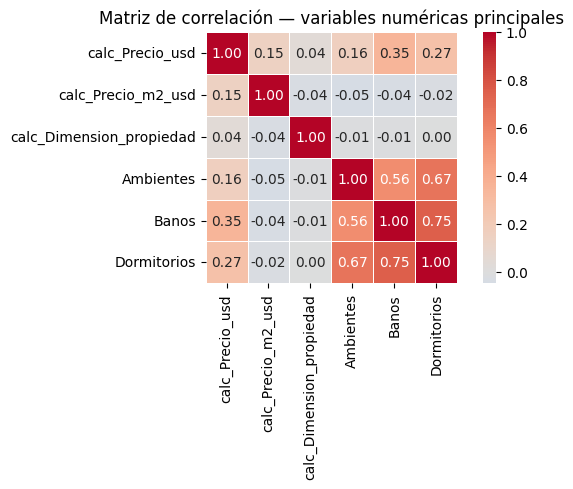

In [79]:
vars_corr = [
    'calc_Precio_usd',
    'calc_Precio_m2_usd',
    'calc_Dimension_propiedad',
    'Ambientes',
    'Banos',
    'Dormitorios',
]

corr_matrix = df[vars_corr].corr()

display(corr_matrix.round(2))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Matriz de correlación — variables numéricas principales')
plt.tight_layout()
plt.show()

**Interpretación:**

- `Banos` es la variable con mayor correlación con `calc_Precio_usd`
  (0.37), seguida de `Dormitorios` (0.34) y `Ambientes` (0.19).
  Las correlaciones son bajas a moderadas, lo que indica que
  ninguna variable numérica por sí sola explica el precio.
- `calc_Dimension_propiedad` tiene una correlación prácticamente
  nula con `calc_Precio_usd` (0.02). Esto se explica porque el
  dataset mezcla tipos de propiedad con lógicas muy distintas:
  un terreno de 5.000 m² puede costar menos que un apartamento
  de 50 m² bien ubicado. Al analizar todos los tipos juntos, los
  efectos se cancelan entre sí.
- `calc_Precio_m2_usd` no tiene correlación lineal con ninguna
  variable de tamaño (valores entre -0.05 y 0.09), lo que confirma
  que el precio por metro cuadrado está determinado principalmente
  por factores no capturados en estas variables numéricas,
  como la ubicación.
- `Ambientes`, `Dormitorios` y `Banos` están moderadamente
  correlacionados entre sí (0.53–0.72), ya que miden distintos
  aspectos del tamaño funcional de una propiedad.

> **Nota metodológica:** Las correlaciones bajas con el precio son
> en parte consecuencia de analizar el dataset completo con tipos
> de propiedad heterogéneos (apartamentos, casas, terrenos). Al
> mezclar tipos con lógicas de precio distintas, las relaciones
> lineales se diluyen. Este es uno de los argumentos más concretos
> para acotar el análisis a un tipo de propiedad específico en
> entregas futuras.

> **Conexión con la Entrega 1 — Pregunta 1:** *¿Cuáles son los
> factores más relacionados con el precio?* En el dataset completo,
> la cantidad de baños es el predictor numérico más asociado al
> precio (0.37), aunque la relación es moderada. La ubicación
> geográfica, variable categórica, probablemente explique más
> variación que cualquier variable numérica individual.

### Precio según zona geográfica

Se analiza cómo varía el precio en USD según la zona, calculando
mediana, media y desvío estándar por grupo. Se usa la mediana como
medida de referencia para reducir el efecto de los valores extremos
identificados en el análisis descriptivo.

A diferencia de la tabla de frecuencias de la sección anterior que
mostraba las 10 zonas más frecuentes, aquí se incluyen todas las
zonas del dataset para tener una visión completa, aunque muchas
tienen muestras muy pequeñas que limitan su interpretación.

In [80]:
precio_por_zona = (
    df.groupby('Zona', observed=True)['calc_Precio_usd']
    .agg(
        n='count',
        mediana='median',
        media='mean',
        desvio='std'
    )
    .sort_values('mediana', ascending=False)
    .round(0)
)

display(precio_por_zona)

,n,mediana,media,desvio
Zona,,,,
Entre Ríos,3,280000.0,273333.0,30551.0
Otros Paises,27,181414.0,217820.0,173042.0
Tucumán,7,165000.0,196429.0,164310.0
Capital Federal,148,160000.0,183933.0,133823.0
GBA Norte,146,120000.0,157640.0,140630.0
Neuquén,16,110000.0,124812.0,83057.0
Buenos Aires (fuera de GBA),18,96500.0,137673.0,113625.0
Santa Fe,77,95000.0,141143.0,122848.0
Buenos Aires Costa Atlántica,90,95000.0,129389.0,127721.0


**Interpretación:**

- **Capital Federal** presenta la mediana más alta entre las zonas
  con muestra representativa (USD 115.000, n=162), seguida de
  **GBA Norte** (USD 102.500, n=142).
- Las zonas del interior con muestras razonables muestran precios
  significativamente menores: **Córdoba** USD 75.500 (n=70),
  **Santa Fe** USD 89.500 (n=76), **Mendoza** USD 59.450 (n=26).
- **Entre Ríos** aparece con la mediana más alta del dataset
  (USD 280.000), pero con solo 3 registros: no es un dato
  estadísticamente representativo y debe interpretarse con cautela.
- Lo mismo aplica para zonas como Santa Cruz (n=1, mediana USD 433),
  Misiones (n=1, mediana USD 43) o Corrientes (n=1): estos valores
  no reflejan el mercado real de esas provincias sino registros
  individuales probablemente con errores de carga.
- La diferencia entre Capital Federal y Mendoza supera el doble en
  términos de mediana (USD 115.000 vs USD 59.450), confirmando que
  la ubicación geográfica es uno de los factores de mayor impacto
  en el precio.

> **Limitación del dataset:** 13 de las 22 zonas tienen menos de
> 20 registros, lo que impide extraer conclusiones estadísticas
> confiables para buena parte del interior del país. El análisis
> geográfico es representativo principalmente para la región
> metropolitana (Capital Federal, GBA Norte, GBA Sur, GBA Oeste)
> y las provincias de Santa Fe y Córdoba.

> **Conexión con la Entrega 1 — Pregunta 2:** *¿Cómo varían los
> precios entre distintas zonas?* La región metropolitana concentra
> los precios más altos y la mayor cantidad de registros. El
> interior está subrepresentado, lo que limita la comparación
> nacional.

### Precio según tipo de propiedad

Se calcula el mismo resumen estadístico por tipo de propiedad,
filtrando los tipos con menos de 10 registros para asegurar
representatividad estadística mínima en cada grupo.

In [81]:
tipos_validos = df['Tipo'].value_counts()
tipos_validos = tipos_validos[tipos_validos >= 10].index

precio_por_tipo = (
    df[df['Tipo'].isin(tipos_validos)]
    .groupby('Tipo', observed=True)['calc_Precio_usd']
    .agg(
        n='count',
        mediana='median',
        media='mean',
        desvio='std'
    )
    .sort_values('mediana', ascending=False)
    .round(0)
)

display(precio_por_tipo)

,n,mediana,media,desvio
Tipo,,,,
Casa,266,152500.0,181864.0,132964.0
Local Comercial,28,129250.0,184655.0,153437.0
Apartamento,322,105000.0,140791.0,116099.0
PH,40,81000.0,117137.0,106175.0
Oficina comercial,23,75000.0,116477.0,109762.0
Terrenos,158,65000.0,100161.0,105755.0


**Interpretación:**

- **Casa** tiene la mediana más alta (USD 135.000, n=251), seguida
  de **local comercial** (USD 99.000, n=29) y **apartamento**
  (USD 91.258, n=340).
- **Apartamento** es el tipo con más registros (340) y el segundo
  precio mediano más alto entre residenciales, lo que lo convierte
  en el tipo más representativo del dataset.
- **Terrenos** tienen una mediana de USD 63.500 (n=156), coherente
  con su bajo precio por m² observado en el análisis descriptivo.
- **Bodega-galpón** presenta el caso más extremo de distorsión:
  mediana USD 6.950 pero media USD 68.881, con un desvío de
  USD 110.993 superior a la propia media. Esto indica que unos
  pocos registros de alto valor inflan completamente la media,
  haciendo que la mediana y la media sean prácticamente
  incomparables para este tipo.
- El **desvío estándar alto en todos los tipos** (entre USD 63.000
  y USD 119.000) confirma que dentro de cada categoría hay alta
  variabilidad: el tipo de propiedad solo no es suficiente para
  explicar el precio. La zona geográfica actúa como factor
  moderador dentro de cada tipo.

> **Conexión con la Entrega 1 — Pregunta 3:** *¿Qué tipos
> predominan y cómo se diferencian en precio?* Casa y apartamento
> concentran el 68% del dataset y presentan los precios medianos
> más altos entre los tipos residenciales, pero la dispersión
> interna de cada tipo es tan alta que el tipo solo no alcanza
> para predecir el precio.

### Asociación entre variables categóricas: Tipo y Zona

Para explorar si existe asociación entre el tipo de propiedad y la
zona geográfica se construye una tabla de contingencia (crosstab).
Esto permite identificar si ciertos tipos de propiedad se
concentran en determinadas zonas.

In [82]:
tipos_principales = ['apartamento', 'casa', 'terrenos']

crosstab_abs = pd.crosstab(
    df[df['Tipo'].isin(tipos_principales)]['Zona'],
    df[df['Tipo'].isin(tipos_principales)]['Tipo'],
)

crosstab_pct = pd.crosstab(
    df[df['Tipo'].isin(tipos_principales)]['Zona'],
    df[df['Tipo'].isin(tipos_principales)]['Tipo'],
    normalize='index'
).round(2) * 100

print("Tabla de contingencia — frecuencias absolutas:")
display(crosstab_abs)

print("\nTabla de contingencia — porcentaje por zona (fila):")
display(crosstab_pct)

Tabla de contingencia — frecuencias absolutas:


Tipo
Zona



Tabla de contingencia — porcentaje por zona (fila):


Tipo
Zona


**Interpretación:**

- **Capital Federal** es la zona más homogénea en tipo: 89% de sus
  propiedades son apartamentos, solo 7% casas y 4% terrenos.
  Esto refleja la estructura urbana densa de la ciudad.
- **GBA Oeste y GBA Sur** muestran el patrón opuesto: 54% y 50%
  casas respectivamente, con menor presencia de apartamentos
  (32% y 25%). Reflejan un mercado más horizontal y familiar.
- **GBA Norte** tiene una distribución equilibrada entre los tres
  tipos (30% apartamentos, 40% casas, 30% terrenos), lo que
  sugiere mayor heterogeneidad de oferta en esa zona.
- **Santa Fe** se asemeja más a Capital Federal que al GBA en
  cuanto a composición: 60% apartamentos, lo que es consistente
  con el peso de Rosario como ciudad densamente urbanizada.
- Varias zonas del interior tienen muestras tan pequeñas que sus
  porcentajes no son informativos (Chubut, Jujuy, Tierra del Fuego:
  100% de un solo tipo con n ≤ 4 registros).
- La asociación entre tipo y zona confirma que **no es posible
  analizar el tipo de propiedad de forma independiente a la
  ubicación**: el mix de tipos varía sistemáticamente según la
  zona, lo que implica que cualquier comparación de precios entre
  zonas está también comparando distintos tipos de propiedades.

> **Síntesis de la sección:** Los hallazgos principales son tres.
> Primero, las correlaciones numéricas con el precio son bajas
> (máximo 0.37 para Banos), en parte porque el dataset mezcla
> tipos de propiedad con lógicas de precio muy distintas. Segundo,
> la zona geográfica diferencia los precios de forma más marcada
> que cualquier variable numérica individual: la diferencia entre
> Capital Federal y Mendoza supera el doble. Tercero, tipo y zona
> están asociados entre sí: Capital Federal es casi exclusivamente
> apartamentos mientras que GBA Oeste/Sur son mayoritariamente
> casas, lo que impide analizar ambas variables de forma aislada.
> Estos tres hallazgos refuerzan la recomendación de la cátedra de
> acotar el análisis a un tipo de propiedad y una región para la
> siguiente entrega.

## Uso de herramientas de Inteligencia Artificial

En el desarrollo de este trabajo se utilizó **Claude (Anthropic)** 
como herramienta de apoyo en las siguientes instancias:

- **Redacción y revisión de texto:** asistencia en la redacción de
  interpretaciones y celdas Markdown para mejorar la claridad y
  precisión del lenguaje técnico.
- **Código Python:** soporte en la escritura y depuración de código
  para transformaciones de datos, cálculos estadísticos y
  visualizaciones.
- **Revisión de criterios analíticos:** consultas sobre decisiones
  metodológicas (estrategias de imputación, selección de variables,
  interpretación de correlaciones).

En todos los casos, el grupo revisó, validó y adaptó los resultados
generados, asumiendo la responsabilidad sobre las decisiones 
analíticas tomadas.